# Mother machine simulations

In [1]:
%load_ext autoreload
%autoreload 2
import os
os.environ['DISPLAY'] = ':1'


In [2]:
import sys

from SyMBac.simulation import Simulation
from SyMBac.PSF import PSF_generator
from SyMBac.renderer import Renderer
from SyMBac.PSF import Camera
from SyMBac.misc import get_sample_images
import matplotlib.pyplot as plt

In [3]:
import dask.array as da

In [4]:
images = da.from_zarr("/data/scientific_data/20260109_SB7_exit_snake.trenches.zarr/data")

In [5]:
images

dask.array<from-zarr, shape=(1009, 750, 2, 164, 34), dtype=uint16, chunksize=(1, 750, 1, 164, 34), chunktype=numpy.ndarray>

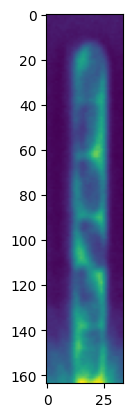

In [6]:
real_image = images[10,400,0].compute()
plt.imshow(real_image)

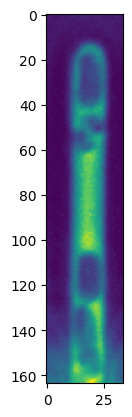

In [7]:
# get a random assortment of real images in a list from images[:,:,0] and compute them
real_images = [images[i,j,0].compute() for i in range(10) for j in range(10)]
plt.imshow(real_images[0])

## Running a simulation

Mother machine simulations are handled with the  `Simulation` class.

Instantiating a `Simulation` object requires the following arguments to be specified:

- *trench_length*: The length of the trench.
- *trench_width*: The width of the trench.
- *cell_max_length*: The maximum allowable length of a cell in the simulation.
- *cell_width*: The average width of cells in the simulation.
- *sim_length*: The number of timesteps to run the simulation for.
- *pix_mic_conv*: The number of microns per pixel in the simulation. 
- *gravity*: The strength of the arbitrary gravity force in the simulations.
- *phys_iters*: The number of iterations of the rigid body physics solver to run each timestep. Note that this affects how gravity works in the simulation, as gravity is applied every physics iteration, higher values of *phys_iters* will result in more gravity if it is turned on.
- *max_length_std*: The standard deviation of the normal distribution centered on *cell_max_length*. Maximum lengths are sampled per cell at birth/division and remain centered on *cell_max_length* (no lineage drift).
- *width_std*: The standard deviation of the normal distribution centered on *cell_width*. Width targets are sampled at division and then relaxed smoothly over time to avoid abrupt size jumps.
- *save_dir*: The save location of the return value of the function. The output will be pickled and saved here, so that the simulation can be reloaded later withuot having to rerun it, for reproducibility. If you don't want to save it, just leave it as /tmp/`.

In [21]:
my_simulation = Simulation(
    trench_length=15,
    trench_width=1.45,
    cell_max_length=3.4, #6, long cells # 1.65 short cells
    cell_width= 1., #1 long cells # 0.95 short cells
    sim_length = 1500,
    pix_mic_conv = 0.1079,
    gravity=0,
    phys_iters=15,
    max_length_std = 2.5,
    width_std = 0.25,
    lysis_p = 0.0075,
    save_dir="/data/scientific_data/sim_1_small/",
    resize_amount = 3,
    substeps=50
)

In [22]:
my_simulation.run_simulation(show_window=True)

/home/georgeos/Documents/GitHub/SyMBac/SyMBac/physics/microfluidic_geometry.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  return -x / np.sqrt(r**2 - x**2)


Running simulation:   0%|          | 0/1502 [00:00<?, ?it/s]

This method takes two arguments. 

- *do_transformation* - Whether or not to bend or morph the cells to increase realism.
- *label_masks* - This controls whether the output training masks will be binary or labeled. Binary masks are used to train U-net (e.g DeLTA), wheras labeled masks are used to train Omnipose

In [23]:
my_simulation.draw_simulation_OPL(do_transformation=False, label_masks=True)

Rendering cell optical path lengths:   0%|          | 0/1500 [00:00<?, ?it/s]

## Simulation visualisation

We can visualise one of the OPL images and masks from the simulation:

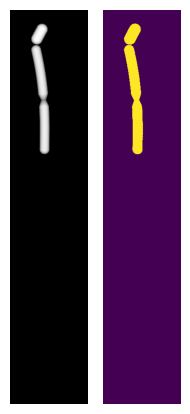

In [24]:
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(2,5))
ax1.imshow(my_simulation.OPL_scenes[-1], cmap="Greys_r")
ax1.axis("off")
ax2.imshow(my_simulation.masks[-1])
ax2.axis("off")
plt.tight_layout()

In [25]:
my_simulation.visualise_in_napari()

Exception ignored in: <function ShaderProgram.__del__ at 0x78866158aac0>
Traceback (most recent call last):
  File "/home/georgeos/Documents/GitHub/SyMBac/.pixi/envs/default/lib/python3.12/site-packages/pyglet/graphics/shader.py", line 1400, in __del__
    self._context.delete_shader_program(self._id)
  File "/home/georgeos/Documents/GitHub/SyMBac/.pixi/envs/default/lib/python3.12/site-packages/pyglet/gl/base.py", line 445, in delete_shader_program
    gl.glDeleteProgram(gl.GLuint(program_id))
  File "/home/georgeos/Documents/GitHub/SyMBac/.pixi/envs/default/lib/python3.12/site-packages/pyglet/gl/lib.py", line 83, in errcheck
    raise GLException(msg)
pyglet.gl.lib.GLException: (0x1281): Invalid value. A numeric argument is out of range.
Exception ignored in: <function ShaderProgram.__del__ at 0x78866158aac0>
Traceback (most recent call last):
  File "/home/georgeos/Documents/GitHub/SyMBac/.pixi/envs/default/lib/python3.12/site-packages/pyglet/graphics/shader.py", line 1400, in __del_

## Point spread function (PSF) generation

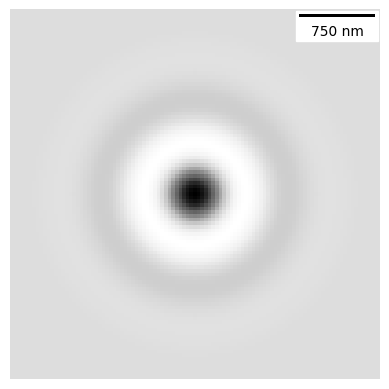

In [26]:
# A phase contrast kernel
my_kernel = PSF_generator(
    radius = 50, 
    wavelength = 0.7, 
    NA = 0.95, 
    n = 1.0, 
    resize_amount = 3, 
    pix_mic_conv = 0.1079, 
    apo_sigma = 20, 
    mode="phase contrast", 
    condenser = "Ph2")
my_kernel.calculate_PSF()
my_kernel.plot_PSF()

## Camera model

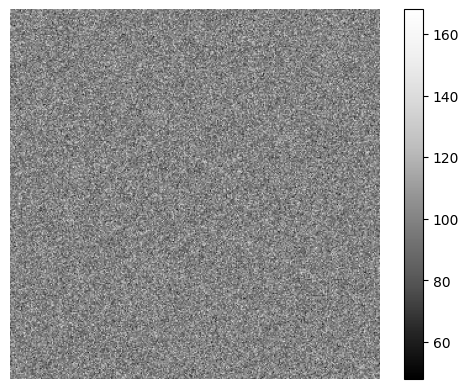

In [27]:
my_camera = Camera(baseline=100, sensitivity=2.9, dark_noise=8)
my_camera.render_dark_image(size=(300,300));

In [28]:
my_renderer = Renderer(simulation = my_simulation, PSF = my_kernel, real_image = real_image, camera = my_camera, additional_real_images = real_images)

3 (894, 162)


## Automatic image optimisation (recommended)

Instead of manually adjusting sliders, you can use the `AutoOptimiser` to automatically find optimal rendering parameters. This uses Bayesian optimisation (Optuna) with a composite loss function that compares intensity histograms, power spectral density, texture features, contrast ratios, and higher-order statistics between synthetic and real images.

The optimiser runs in two phases:
1. **TPE search** — explores the parameter space efficiently using a Tree-structured Parzen Estimator
2. **CMA-ES refinement** — fine-tunes continuous parameters around the best solution found

In [29]:
# from SyMBac.auto_optimise import AutoOptimiser

# optimiser = AutoOptimiser(
#     renderer=my_renderer,
#     real_images=real_images,
#     n_trials=300,          # Number of optimisation trials
#     timeout=600,           # Max time in seconds (10 min)
#     n_scenes_per_eval=4,   # Scenes averaged per trial (reduces noise)
#     optimise_psf=False,     # Set True to also optimise PSF parameters
#     intensity_order=["media", "cell", "device"],  # brightest to darkest
# )
# best_params = optimiser.optimise()

In [30]:
# # View optimisation results: loss history, parameter importance, and best vs real comparison
# optimiser.plot_results()
# print(optimiser.get_best_params_summary())

In [31]:
# # Apply the best parameters to the renderer for training data generation
# optimiser.apply_to_renderer()

## Manual image optimisation (alternative)

If you prefer to manually tune the rendering parameters using interactive sliders, you can use the original workflow below. This requires labelling regions in napari and adjusting sliders until the synthetic image looks right.

In [32]:
my_renderer.select_intensity_napari()

/home/georgeos/Documents/GitHub/SyMBac/SyMBac/renderer.py:229: FutureWarning: `napari.view_image` is deprecated and will be removed in napari 0.7.0.
Use `viewer = napari.Viewer(); viewer.add_image(...)` instead.
  viewer = napari.view_image(self.real_resize)


In [33]:
my_renderer.optimise_synth_image(manual_update=False, initial_values=None)

interactive(children=(IntSlider(value=75, description='media_multiplier', max=300, min=-300), FloatSlider(valu…

In [34]:
my_renderer.generate_training_data(sample_amount=0.15, randomise_hist_match=True, randomise_noise_match=False, randomise_fourier_match=False, burn_in=75, n_samples = 5000, save_dir="/data/scientific_data/syndata_3_texture_nofourier_randomise_hist_match_smallcells", in_series=False)

Rendering synthetic images: 0it [00:00, ?it/s]